# Viewing specific systems

This notebook is a copy of `view_06.ipynb`, focused on the systems shown in the
reference figures: `00006334`, `00010418`, and `00000367` (`00006334` appears in
two of the figures). It plots each system's exposures across all available bands.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# Open the dataset

Make sure to update the filepath in the block below!

In [4]:
h5_filepath = '/nfsdata2/astromusers/roman_data_challenge/roman_data_challenge_rung_0_6040split_v_1_0.h5'  # TODO update this path!
f = h5py.File(h5_filepath, 'r')

In [5]:
# print all attributes for the root group
for key, value in f.attrs.items():
    print(f"{key}: {value}")

author: ['bwedig@megadon.physics.wustl.edu' 'username@host for calculation']
created: 2026_07_17-12_36_44_AM
dataset_version: 1.0
lenstronomy_version: ['1.13.3' 'lenstronomy version']
mejiro_version: ['3.0.0' 'mejiro version']
romanisim_version: ['0.13.0' 'romanisim version']
slsim_version: ['0.1.1' 'SLSim version']
stpsf_version: ['2.1.0' 'STPSF version']


# What's in this file?

Depending on the configuration used to build it, a dataset may or may not include synthetic images or PSFs. The cell below inspects the file and defines a few variables the rest of the notebook uses, so this notebook runs on any output of `_06_h5_export.py`.

In [6]:
uids = sorted(key.removeprefix('strong_lens_') for key in f['images'].keys())

# inspect the first system to see which bands are present and whether synthetic images were included
first_group = f['images'][f'strong_lens_{uids[0]}']
bands = sorted({key.split('_')[-1] for key in first_group.keys() if key.startswith('exposure_')})
has_synthetic_images = any(key.startswith('synthetic_image_') for key in first_group.keys())
has_psfs = 'psfs' in f

print(f'{len(uids)} systems: {uids[0]} through {uids[-1]}')
print(f'Bands: {", ".join(bands)}')
print(f'Synthetic images included: {has_synthetic_images}')
print(f'PSFs included: {has_psfs}')

8096 systems: 00000000 through 00011178
Bands: F106, F129, F158
Synthetic images included: False
PSFs included: False


# The `images` group

This group contains metadata about each strong lens system (e.g., redshifts, Einstein radius, SNR, etc.) and synthetic images and exposures for each filter.

## Retrieve the metadata for a given system

In [7]:
# the four systems of interest, pulled from the reference figures
# (00006334 appears in two of the figures)
target_uids = ['00006334', '00010418', '00000367']

# select one system by its unique identifier for the single-system cells below
uid = target_uids[0]

# print all attributes for the "strong_lens" group
for key, value in f['images'][f'strong_lens_{uid}'].attrs.items():
    print(f"{key}: {value}")

deflector_only: ['False'
 'Only the deflector (lens galaxy) light was simulated; no source/lensing']
detector: ['11' 'Detector']
detector_position_x: ['510' 'Detector X position']
detector_position_y: ['2554' 'Detector Y position']
main_halo_mass: ['39859525880458.17' 'Lens galaxy main halo mass [M_sun]']
mu: ['4.9021138342993105' 'Flux-weighted magnification of source']
sigma_v: ['285.7614755309229' 'Lens galaxy velocity dispersion [km/s]']
substructure: ['False' 'Is substructure present in this lens?']
theta_e: ['2.839653357804197' 'Einstein radius [arcsec]']
uid: ['00006334' 'Unique identifier for system assigned by mejiro']
z_lens: ['0.2819999999999998' 'Lens galaxy redshift']
z_source: ['1.4648801798371327' 'Source galaxy redshift']


## View synthetic image and exposure

In [8]:
# specify band; fall back to the first available band if this file doesn't have it
band = 'F129'
if band not in bands:
    band = bands[0]

group_lens = f['images'][f'strong_lens_{uid}']
exposure = group_lens[f'exposure_{uid}_{band}']

print('Exposure dataset:')
for key, value in exposure.attrs.items():
    print(f"{key}: {value}")

if has_synthetic_images:
    synthetic_image = group_lens[f'synthetic_image_{uid}_{band}']
    print('\nSynthetic image dataset:')
    for key, value in synthetic_image.attrs.items():
        print(f"{key}: {value}")
else:
    synthetic_image = None
    print('\nThis dataset does not include synthetic images.')

Exposure dataset:
exposure_time: ['139.14867999999998' 'Exposure time [seconds]']
filter: ['F129' 'Filter']
fov: ['10.01' 'Field of view [arcsec]']
lens_magnitude: ['16.530220571920083' 'Lens galaxy magnitude']
lensed_source_magnitude: ['21.461731612021165' 'Lensed source galaxy magnitude']
pixel_scale: ['0.11' 'Pixel scale [arcsec/pixel]']
snr: ['64.952790970004' 'Signal-to-noise ratio']
source_magnitude: ['23.187690091996966' 'Unlensed source galaxy magnitude']
units: ['DN/s' 'Units of pixel values']

This dataset does not include synthetic images.


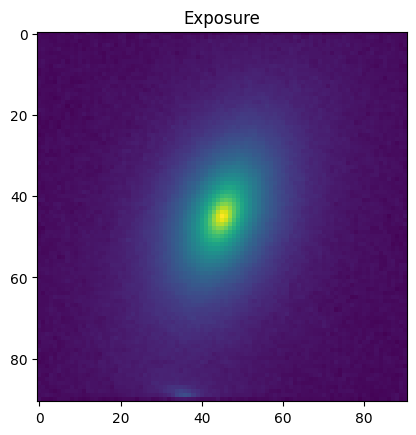

In [9]:
panels = [('Exposure', exposure)]
if has_synthetic_images:
    panels.insert(0, ('Synthetic Image', synthetic_image))

_, ax = plt.subplots(1, len(panels), squeeze=False)
for i, (title, dataset) in enumerate(panels):
    ax[0][i].imshow(dataset, norm=LogNorm())
    ax[0][i].set_title(title)
plt.savefig('figures/06/synthetic_image_vs_exposure.png', dpi=300)
plt.show()

## Exposures for the systems of interest

One row per system, one column per band, matching the layout of the reference figures.

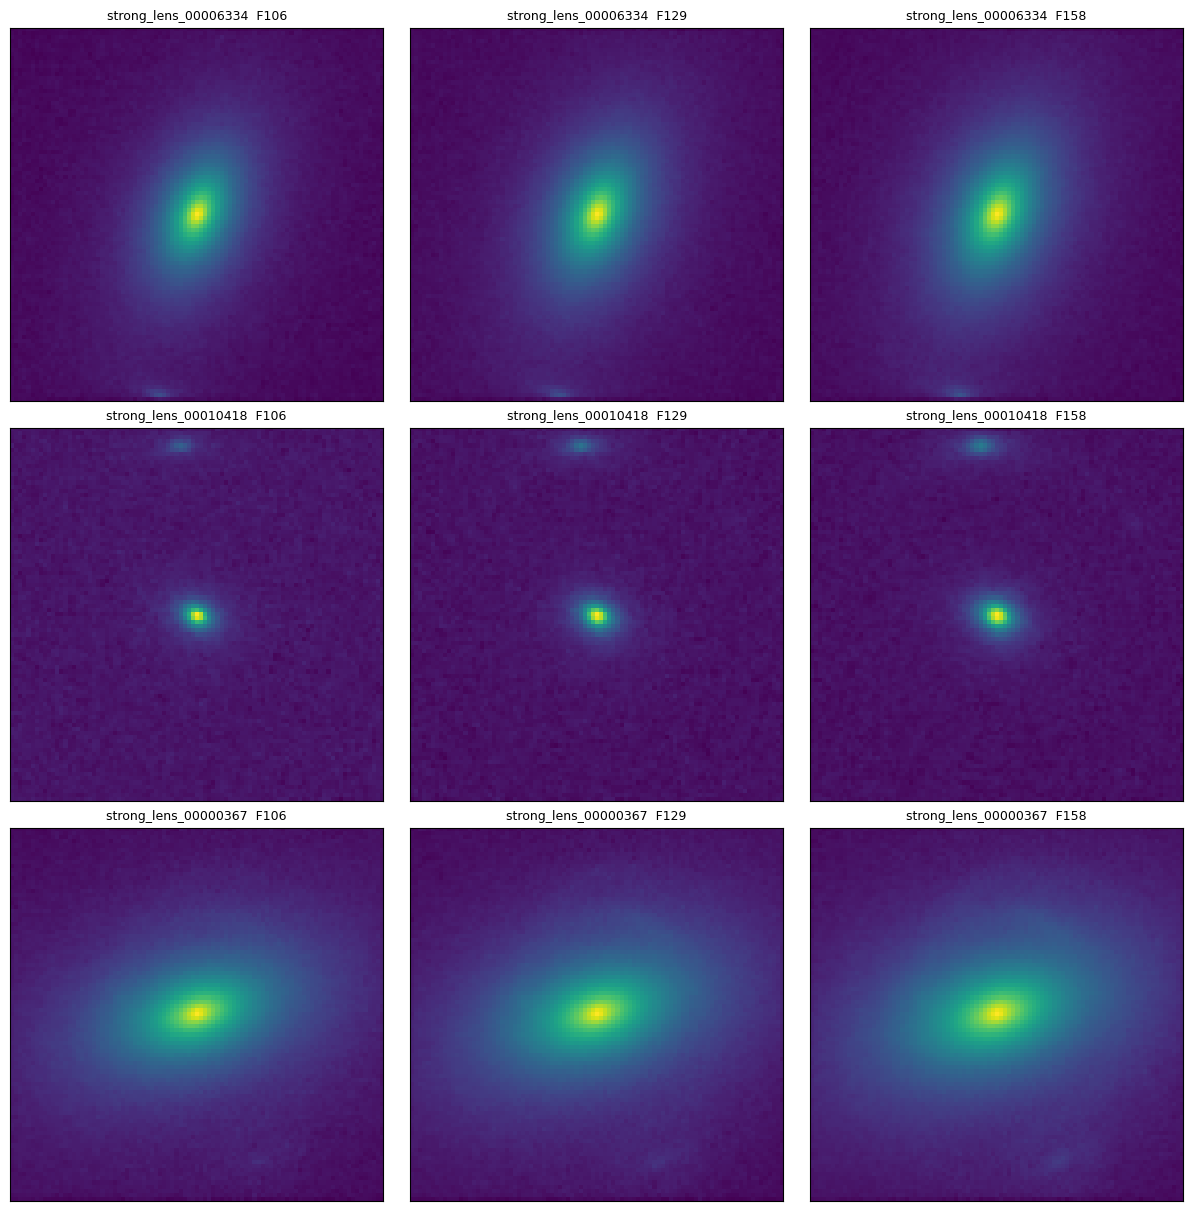

In [13]:
fig, axes = plt.subplots(len(target_uids), len(bands),
                         figsize=(4 * len(bands), 4 * len(target_uids)),
                         squeeze=False, constrained_layout=True)

for row, target_uid in enumerate(target_uids):
    group = f['images'][f'strong_lens_{target_uid}']
    for col, plot_band in enumerate(bands):
        ax = axes[row][col]
        exposure_data = group[f'exposure_{target_uid}_{plot_band}'][()]
        ax.imshow(exposure_data, norm=LogNorm())
        ax.set_title(f'strong_lens_{target_uid}  {plot_band}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

# fig.suptitle('Exposures for the systems of interest')
plt.savefig('figures/06/four_systems_exposures.png', dpi=300)
plt.show()

# The `psfs` group

This group contains the PSFs, if they were included when the dataset was built. The cells below no-op if this file doesn't have them.

## View a PSF

We'll retrieve the PSF associated with the image we looked at above.

In [11]:
# retrieve the detector and detector position metadata, which are attributes on the "strong_lens" group
detector = f['images'][f'strong_lens_{uid}'].attrs['detector'][0]
detector_position_x = f['images'][f'strong_lens_{uid}'].attrs['detector_position_x'][0]
detector_position_y = f['images'][f'strong_lens_{uid}'].attrs['detector_position_y'][0]

print(f"Detector: {detector}")
print(f"Detector Position (x): {detector_position_x}")
print(f"Detector Position (y): {detector_position_y}")

Detector: 11
Detector Position (x): 510
Detector Position (y): 2554


In [12]:
if has_psfs:
    # PSF dataset names encode the band, detector, and detector position, so match on the prefix
    # rather than reconstructing the full name
    sca_group = f['psfs'][f'sca{str(detector).zfill(2)}']
    psf_name = next(key for key in sca_group.keys() if key.startswith(f'psf_{band}_'))
    psf = sca_group[psf_name]

    for key, value in psf.attrs.items():
        print(f"{key}: {value}")

    plt.imshow(np.log10(psf), cmap='inferno')
    plt.colorbar(label=r'$\log_{10}(\text{Fractional Intensity})$')
    plt.title(f'PSF for {band} filter on SCA{str(detector).zfill(2)} at ({detector_position_x}, {detector_position_y})')
    plt.savefig(f'figures/06/psf_{band}_sca{str(detector).zfill(2)}.png', dpi=300)
    plt.show()
else:
    print('This dataset does not include PSFs.')

This dataset does not include PSFs.
